<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/3Credit_Card_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
from __future__ import annotations
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from __future__ import  annotations
import logging
from dataclasses  import dataclass,field
from typing import Optional,Dict,List,Tuple


from scipy.stats import skew as scipy_skew
import scipy.cluster.hierarchy as sch


from sklearn.preprocessing import RobustScaler,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split


from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score,calinski_harabasz_score,davies_bouldin_score



In [90]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s]: %(message)s"
)

logger=logging.getLogger(__name__)

In [91]:
df=pd.read_csv("/content/CC GENERAL.csv")

In [92]:
df.shape

(8950, 18)

**EDA**

In [93]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [94]:
df.dtypes

,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


In [95]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [96]:
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean(),inplace=True)

In [97]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [98]:
df.dropna(inplace=True)

In [99]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [100]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [101]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.00000
mean,1601.041632,0.894951,1025.315149,604.831402,420.794807,994.082050,0.495943,0.205885,0.368778,0.137608,3.313651,15.031492,4522.087829,1784.272537,864.206542,0.159285,11.53375
std,2095.519182,0.207833,2167.010602,1684.222861,917.203254,2121.353259,0.401285,0.300044,0.398090,0.201780,6.912151,25.179530,3659.028526,2909.704331,2372.446607,0.296259,1.31226
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163,0.000000,6.00000
25%,147.838347,0.909091,43.300000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,418.446951,169.123707,0.000000,12.00000
50%,916.749476,1.000000,375.240000,44.990000,94.710000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,896.300688,312.343947,0.000000,12.00000
75%,2104.961701,1.000000,1145.850000,598.950000,484.040000,1131.986387,0.916667,0.333333,0.750000,0.250000,4.000000,18.000000,6500.000000,1951.116757,825.485459,0.166667,12.00000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.00000


In [102]:
df.drop('CUST_ID',axis=1,inplace=True)

univariate

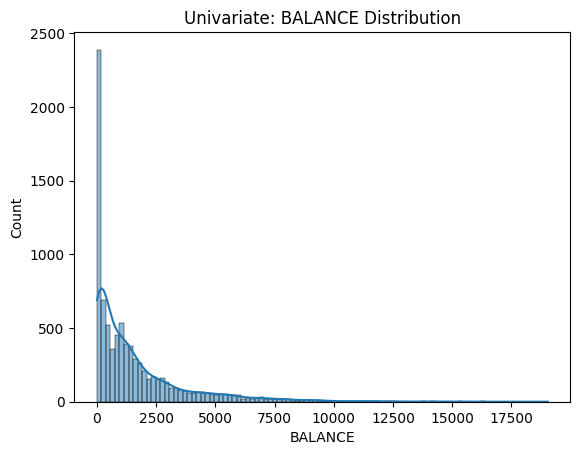

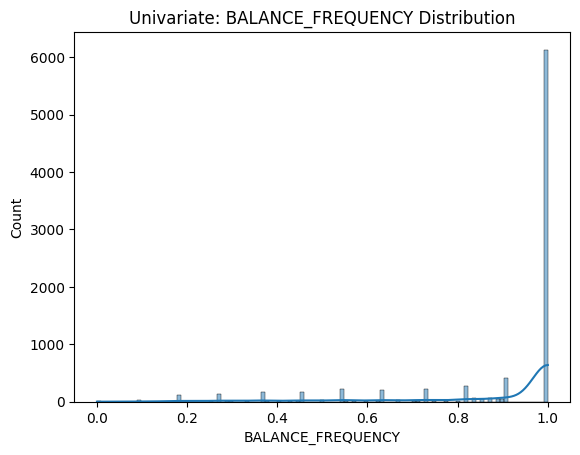

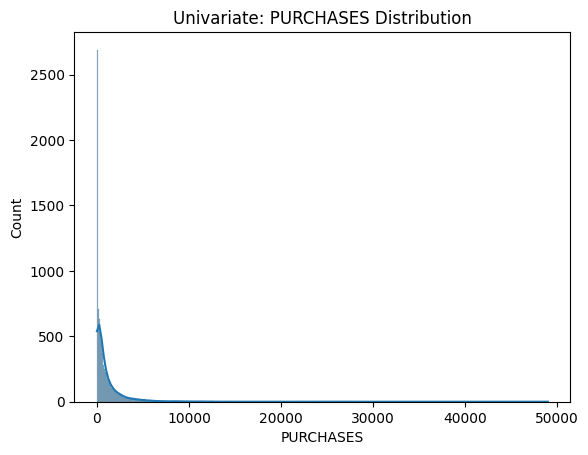

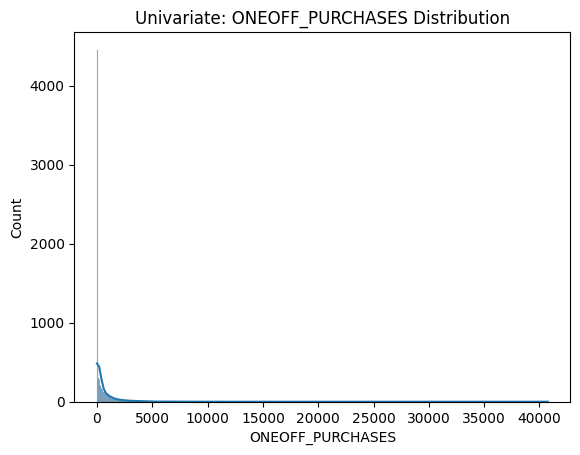

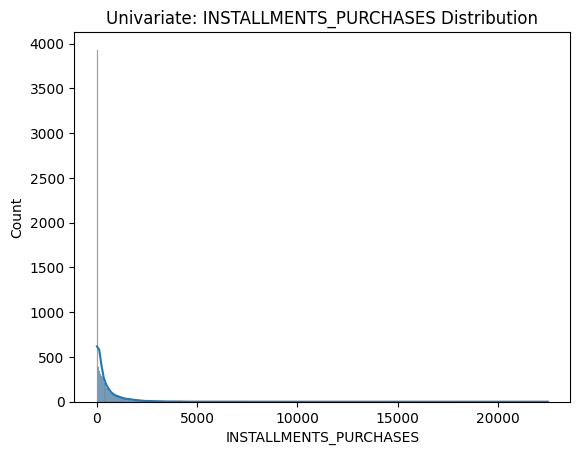

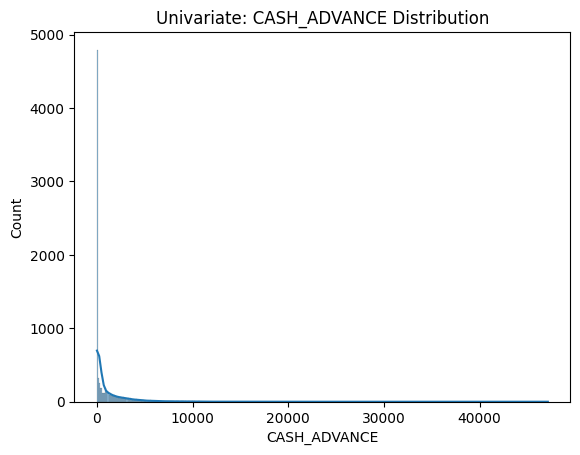

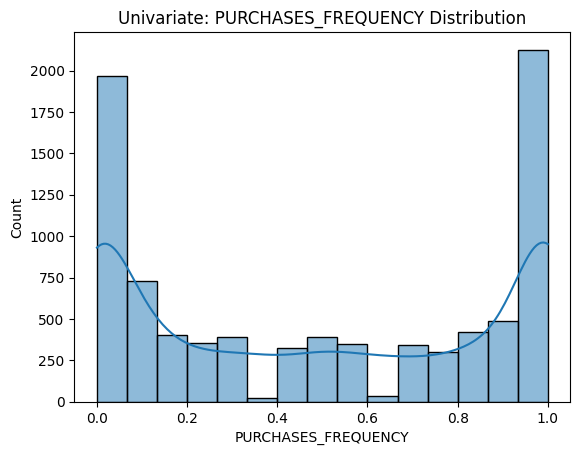

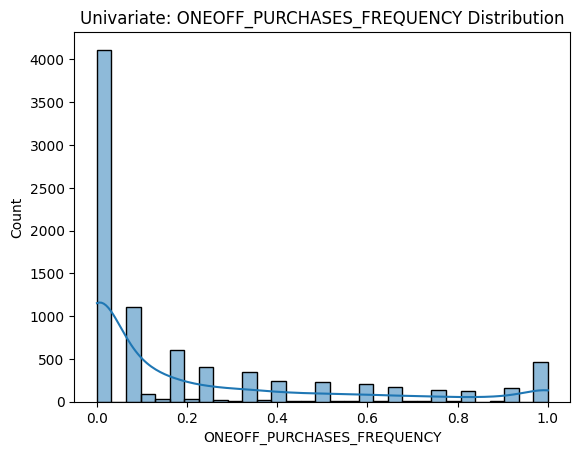

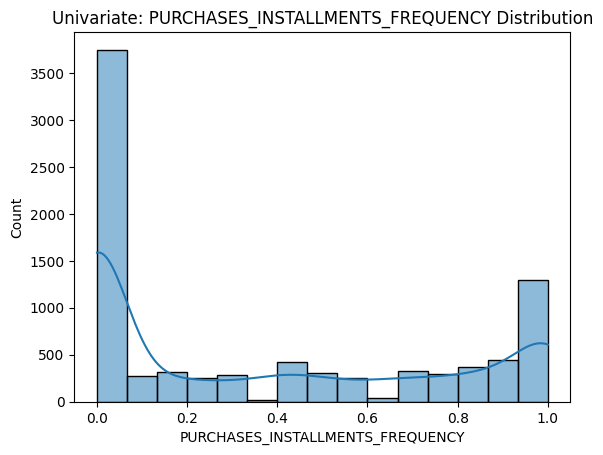

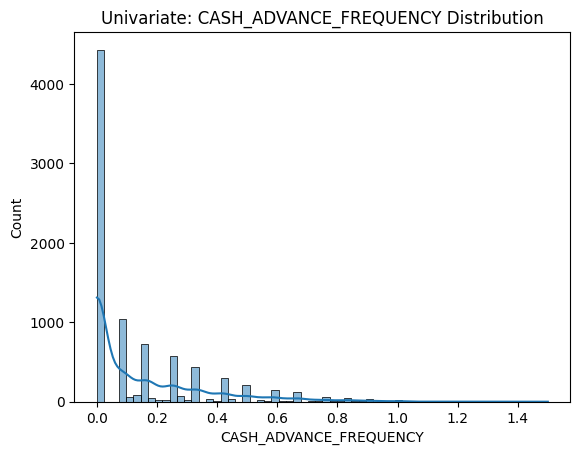

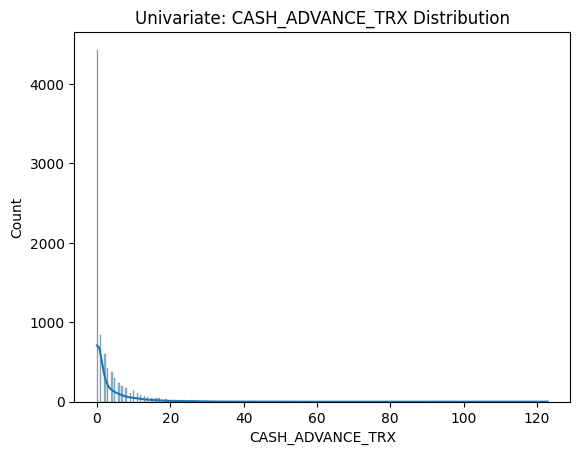

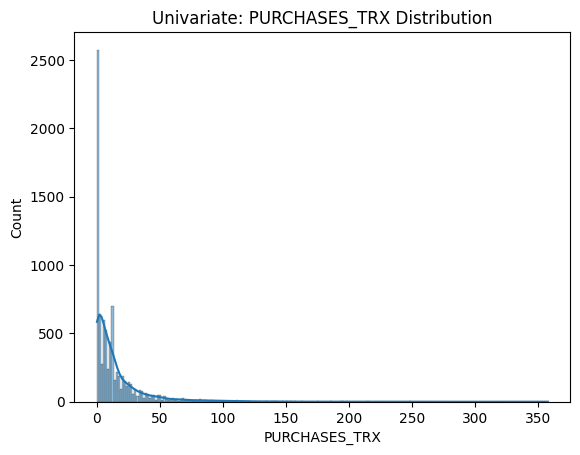

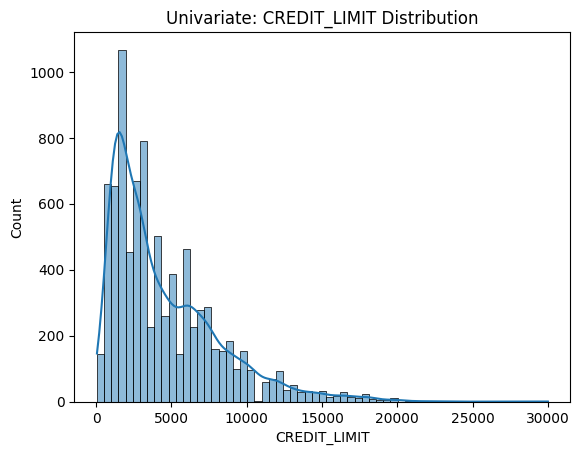

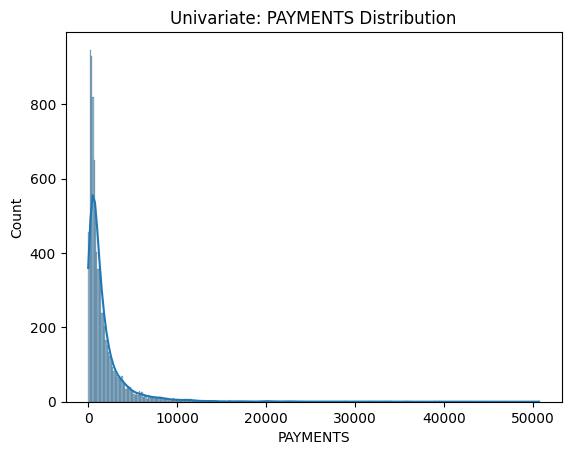

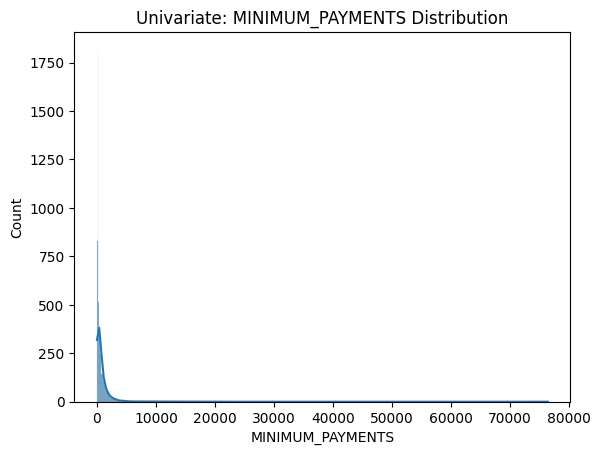

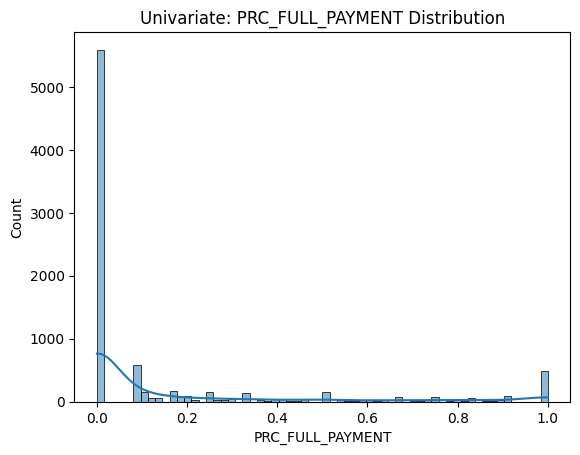

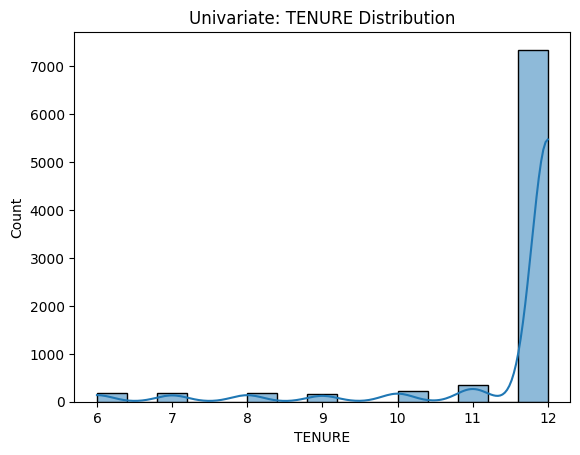

In [103]:
# Visualizing the distribution of a single variable of each features

for column in df.columns:
  sns.histplot(df[column], kde=True)
  plt.title(f'Univariate: {column} Distribution')
  plt.show()



Bivariate

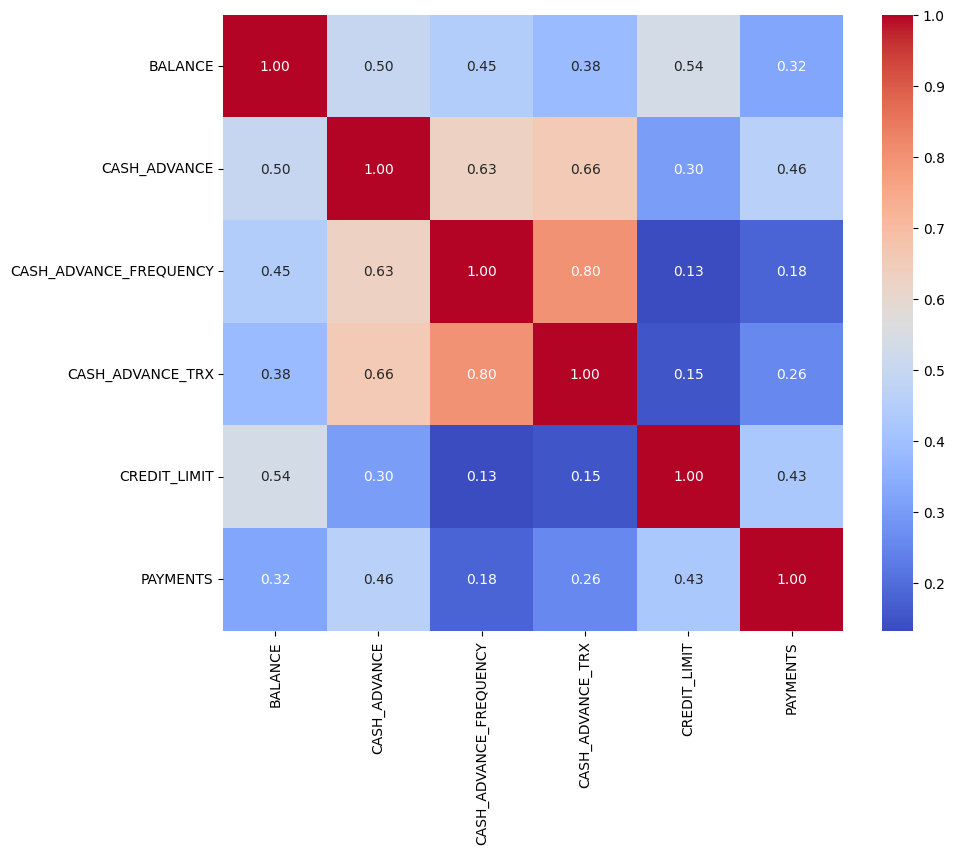

In [104]:
# Keep columns that have a correlation higher than 0.3 with your target
threshold = 0.3
target_col = 'CASH_ADVANCE'

correlations = df.corr()[target_col].abs()
high_corr_cols = correlations[correlations > threshold].index

# Plot only the highly correlated features
plt.figure(figsize=(10, 8))
sns.heatmap(df[high_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()



# **Preprocessing**

In [105]:
num_cols = ['BALANCE','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES','CASH_ADVANCE',
           'CASH_ADVANCE_TRX', 'PURCHASES_TRX','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS','TENURE']

ratio_cols = ['BALANCE_FREQUENCY','PURCHASES_FREQUENCY','ONEOFF_PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY',
             'CASH_ADVANCE_FREQUENCY','PRC_FULL_PAYMENT' ]

In [106]:
X_log=df[num_cols].apply(np.log1p)

In [107]:
scalar=RobustScaler()
scalar.fit(X_log)

RobustScaler()

In [108]:
X_num=scalar.transform(X_log)
X_num = pd.DataFrame(X_num,columns = num_cols)


In [109]:
scalar=StandardScaler()
scalar.fit(df[ratio_cols])
X_ratio=scalar.transform(df[ratio_cols])
X_ratio = pd.DataFrame(X_ratio,columns = ratio_cols)

In [110]:
X_features=pd.concat([X_num,X_ratio],axis=1)

In [111]:
pca=PCA(n_components=0.95)
X_features_pca = pca.fit_transform(X=X_features)

In [112]:
pca.explained_variance_ratio_.cumsum()


array([0.3651757 , 0.58955636, 0.69500509, 0.78465265, 0.85036832,
       0.90107358, 0.92514522, 0.94666054, 0.96783794])

**Train model with kmeans**

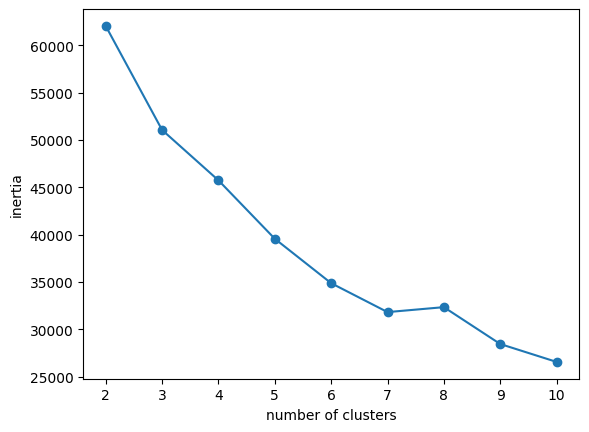

In [113]:
inertia=[]
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(X_features_pca)
  inertia.append(kmeans.inertia_)

plt.plot(range(2,11),inertia,marker = 'o')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.show()

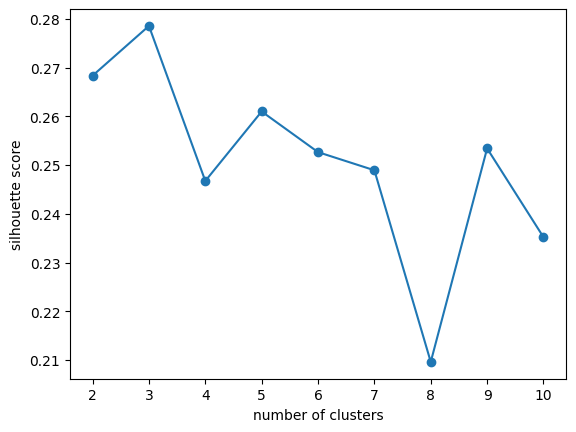

In [114]:
scores=[]
for i in range(2,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(X_features_pca)
  inertia.append(kmeans.inertia_)
  labels  = kmeans.labels_
  scores.append(silhouette_score(X_features_pca,kmeans.labels_))

plt.plot(range(2,11),scores,marker = 'o')
plt.xlabel('number of clusters')
plt.ylabel('silhouette score')
plt.show()

In [115]:
k=3
k_mean=KMeans(n_clusters=k,random_state=42)
k_mean.fit(X_features_pca)
labels=k_mean.labels_

df['clusters']=labels

In [116]:
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,clusters
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6,2
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,1
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,2
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,2


Analysis of clusters

In [117]:
df['clusters'].value_counts()

,count
clusters,
1,4108
0,3132
2,1397


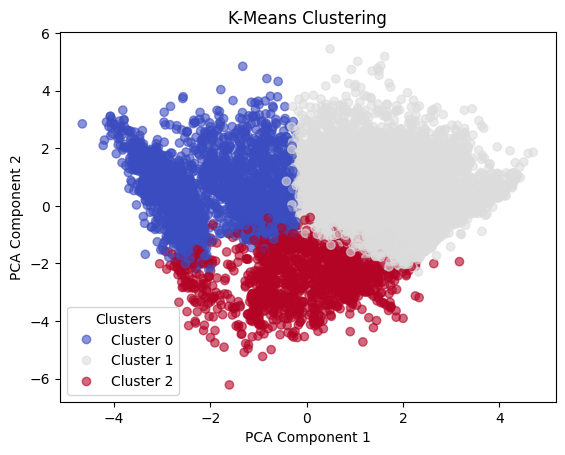

In [118]:
scatter = plt.scatter(X_features_pca[:, 0], X_features_pca[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering')
legend_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels , title="Clusters")
plt.show()

In [119]:
cluster_summary=df.groupby('clusters').median()
cluster_summary = cluster_summary[['BALANCE','PURCHASES','CASH_ADVANCE',
                               'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']]

cluster_summary

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
clusters,,,,,,
0,1607.059727,0.000,1104.612633,3000.0,815.771567,0.0
1,790.742337,1062.785,0.000000,4000.0,1199.080453,0.0
2,30.530541,220.990,0.000000,2900.0,421.803076,0.1


In [124]:
df_cluster_one=cluster_summary.iloc[0]
df_cluster_two=cluster_summary.iloc[1]
df_cluster_three=cluster_summary.iloc[2]

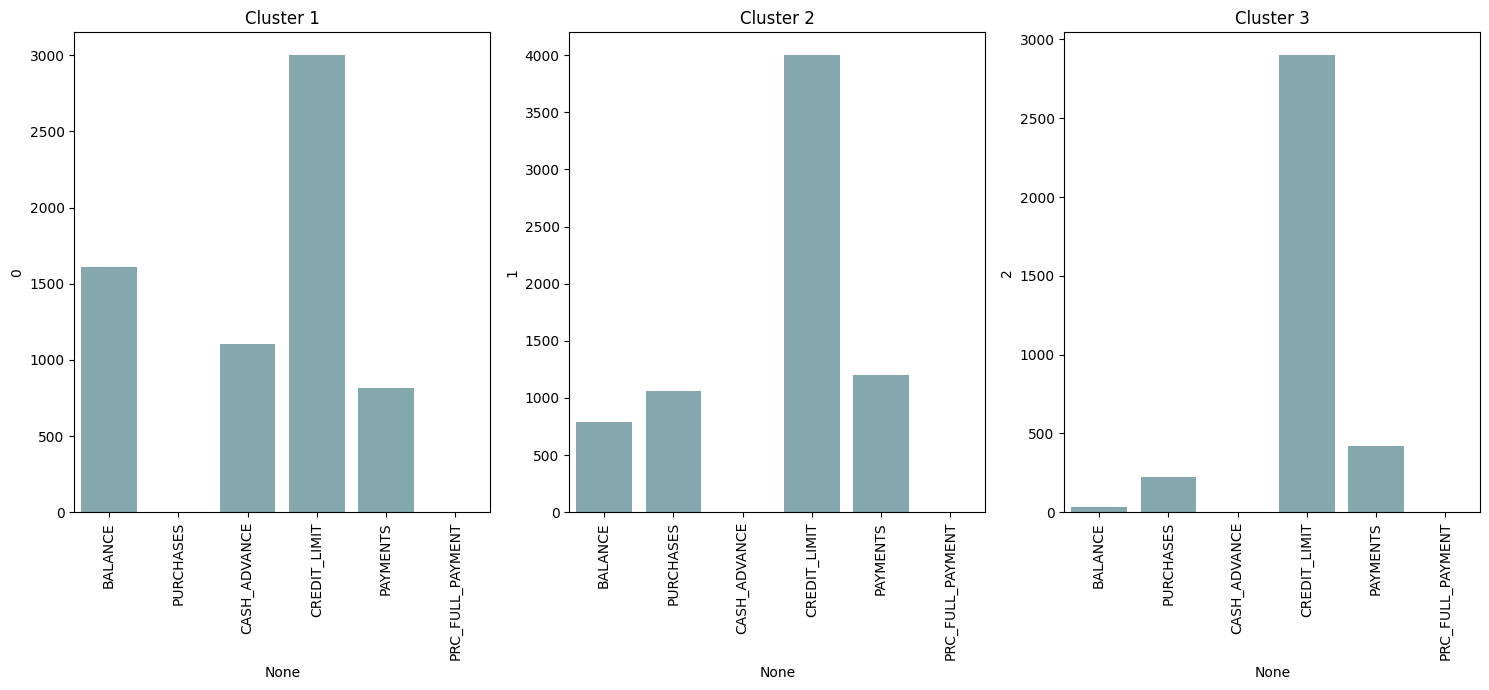

In [125]:
fig , ax = plt.subplots(1,3,figsize = (15,7))

sns.barplot(x = df_cluster_one.index,y = df_cluster_one,ax = ax[0],color='#7EACB5')
ax[0].set_title('Cluster 1')
ax[0].set_xticklabels(df_cluster_one.index,rotation = 90)

sns.barplot(x = df_cluster_two.index,y = df_cluster_two,ax = ax[1],color='#7EACB5')
ax[1].set_title('Cluster 2')
ax[1].set_xticklabels(df_cluster_two.index,rotation = 90)

sns.barplot(x = df_cluster_three.index,y=df_cluster_three,ax = ax[2],color='#7EACB5')
ax[2].set_title('Cluster 3')
ax[2].set_xticklabels(df_cluster_three.index,rotation = 90)

plt.tight_layout()
plt.show()

Train model with Hierarchical Clustering

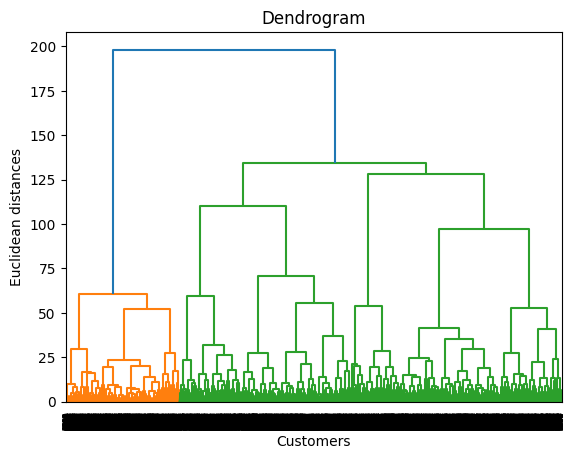

In [128]:
dendrogram = sch.dendrogram(sch.linkage(X_features_pca,method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [130]:
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,clusters
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6,2
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,1
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,2
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,2


In [131]:
df.drop(columns=['clusters'],axis=1)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [134]:
hc=AgglomerativeClustering(n_clusters=3,linkage='ward')
hc.fit_predict(X_features_pca)
labels=hc.labels_
df['clusters']=labels

In [136]:
scores=silhouette_score(X_features_pca,hc.labels_)
print('silhouette_score : ',scores)


silhouette_score :  0.17086839950571825


**Analysis of clusters**

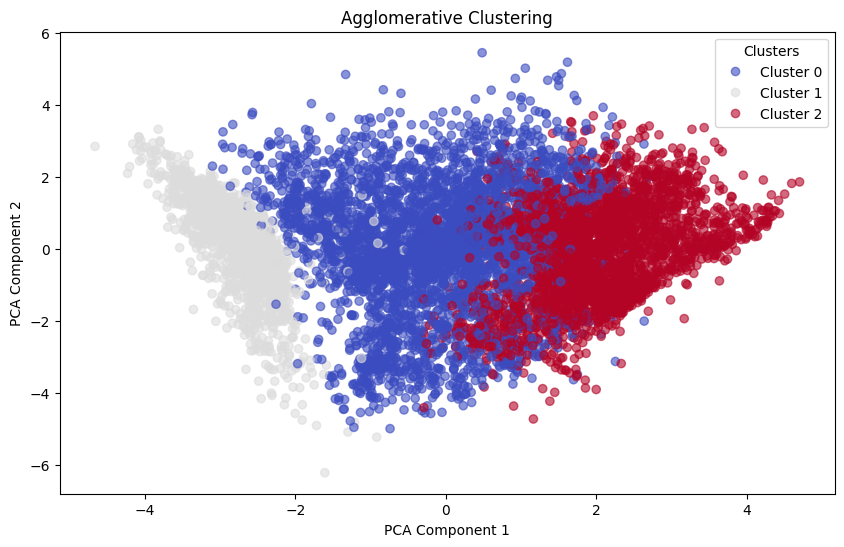

In [138]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_features_pca[:, 0], X_features_pca[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Agglomerative Clustering')
legend_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels , title="Clusters")
plt.show()

In [139]:
df['clusters'].value_counts()

,count
clusters,
0,3662
2,2991
1,1984


In [140]:
hc_summary=df.groupby('clusters').median()
hc_summary = hc_summary[['BALANCE','PURCHASES','CASH_ADVANCE',
                               'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']]

hc_summary

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
clusters,,,,,,
0,990.114507,407.835,0.000000,3100.0,844.355744,0.000000
1,1518.978324,0.000,1194.497821,3000.0,777.534834,0.000000
2,298.592251,1074.290,0.000000,3800.0,1083.783994,0.111111


In [141]:
df_cluster_one = hc_summary.iloc[0]
df_cluster_two = hc_summary.iloc[1]
df_cluster_three = hc_summary.iloc[2]

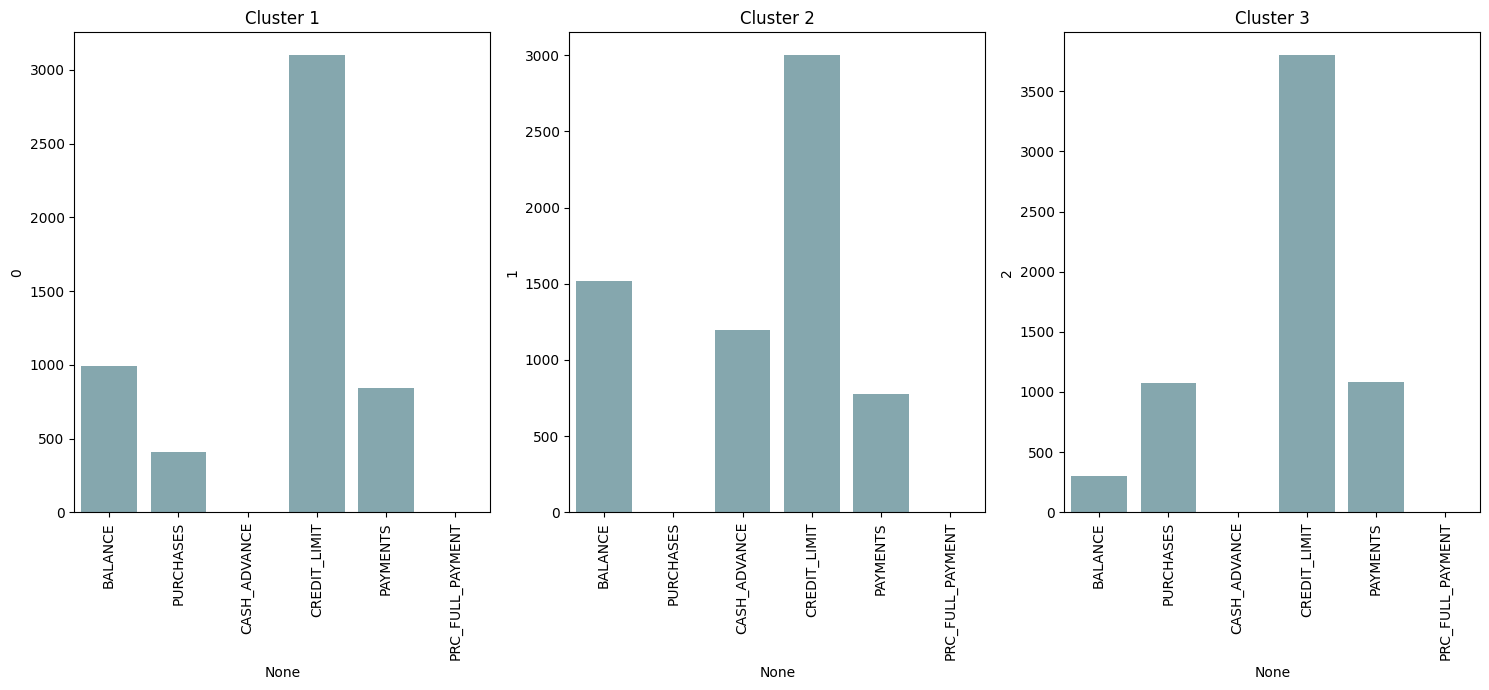

In [142]:
fig , ax = plt.subplots(1,3,figsize = (15,7))

sns.barplot(x = df_cluster_one.index,y = df_cluster_one,ax = ax[0],color='#7EACB5')
ax[0].set_title('Cluster 1')
ax[0].set_xticklabels(df_cluster_one.index,rotation = 90)

sns.barplot(x = df_cluster_two.index,y = df_cluster_two,ax = ax[1],color='#7EACB5')
ax[1].set_title('Cluster 2')
ax[1].set_xticklabels(df_cluster_two.index,rotation = 90)

sns.barplot(x = df_cluster_three.index,y=df_cluster_three,ax = ax[2],color='#7EACB5')
ax[2].set_title('Cluster 3')
ax[2].set_xticklabels(df_cluster_three.index,rotation = 90)

plt.tight_layout()
plt.show()


**Train Model with DBSCAN**

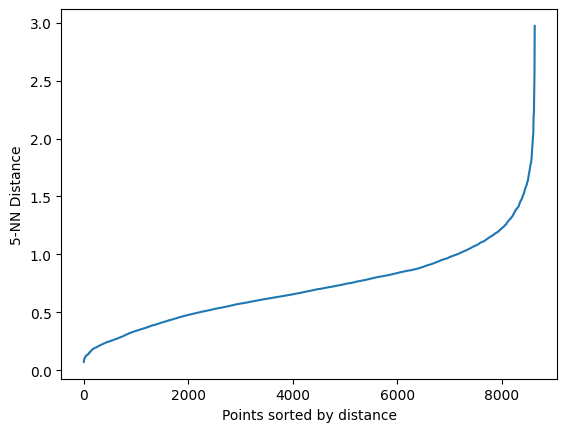

In [147]:
neigboors = NearestNeighbors(n_neighbors = 5)
neigboors_fit= neigboors.fit(X_features_pca)
distances , indices = neigboors_fit.kneighbors(X_features_pca)
distances = distances[:,4]
distances = np.sort(distances)
plt.plot(distances)
plt.ylabel("5-NN Distance")
plt.xlabel("Points sorted by distance")
plt.show()


In [155]:
dbscan = DBSCAN(eps =1.3,min_samples=5)
dbscan.fit(X_features_pca)
labels = dbscan.labels_

df['Cluster'] = labels

In [156]:
score = silhouette_score(X_features_pca[labels!=-1],labels[labels!=-1])
print('silhouette_score : ',score)

silhouette_score :  0.302702441686582


In [158]:
g=df['Cluster'].value_counts()
g

,count
Cluster,
0,8392
-1,226
1,19


In [159]:
legend_labels = []
for i in g.index:
  r = f"Customer{i}"
  legend_labels.append(r)

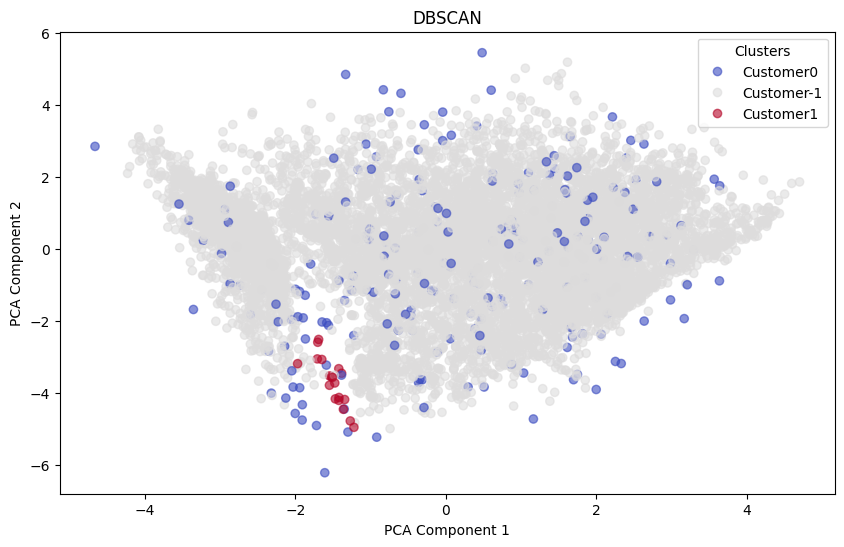

In [161]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_features_pca[:, 0], X_features_pca[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN')
legend_labels = legend_labels
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels , title="Clusters")
plt.show()

In [162]:
df.groupby('Cluster').median()[['BALANCE','PURCHASES',
                                'CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS'
                                ]]

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
Cluster,,,,,
-1,293.251295,647.665,458.010154,4500.0,2806.958197
0,939.127643,373.415,0.000000,3000.0,880.230425
1,10.268192,0.000,469.836414,1200.0,2117.308744
